In [1]:
import sys
sys.path.insert(0, '../')
sys.path.insert(1, '../../')
from build_config import ALL_SEASONS, COMPETITIONS, CURRENT_SEASON, INPUT_CSV_PATHS, TARGET_RANGES
from const import REPO_PATH, RAW_DATA_PATH, PROCESSED_DATA_PATH, MODELS_PATH
from fbref_const import URLs, TARGET_COLUMNS

from src.data.match_data_processing import process_match_target_var, process_match_other_var
from src.feature.feature_encoders import *

import pandas as pd
import os
import numpy as np
import mlflow
import joblib
import tempfile
import os

from build_utils import *

In [2]:
key_columns=['date', 'home', 'away']

In [3]:
team_encoder_path = f"{MODELS_PATH}/data_processors/{COMPETITIONS[0]}/team_encoder.pkl"
encoder = TeamEncoder.load(team_encoder_path)

In [4]:
seasons=sorted(ALL_SEASONS)

In [5]:
test_dict=dict((k, pd.read_csv(f'{REPO_PATH}/{INPUT_CSV_PATHS[k]}')) for k in COMPETITIONS)

In [6]:
for competition in COMPETITIONS:
    test_dict[competition]['date']=pd.to_datetime(test_dict[competition]['date'], format='%Y-%m-%d')

In [9]:
target_dfs[0]['date']

0       December-12-2017
1      September-16-2017
2       December-12-2017
3            May-13-2018
4          April-14-2018
             ...        
375     December-18-2017
376     November-18-2017
377     November-25-2017
378    September-23-2017
379       August-12-2017
Name: date, Length: 380, dtype: object

In [10]:
all_features_dict={}
for competition in COMPETITIONS:
    if competition not in test_dict:
        continue
    test_df = test_dict[competition]
    team_encoder_path = f"{MODELS_PATH}/data_processors/{competition}/team_encoder.pkl"
    season_dfs_dict = {season: pd.read_csv(f"{PROCESSED_DATA_PATH}/{competition}/{season}/all_data_df.csv") for season in seasons}

    target_dfs = {season: pd.read_csv(f"{PROCESSED_DATA_PATH}/{competition}/{season}/all_target_df.csv") for season in seasons}
    # TeamEncoder features
    encoder = TeamEncoder.load(team_encoder_path)
    team_encoder_features = encoder.transform_spot(season_dfs_dict, test_df).reset_index(drop=True)

    # TeamLagFeatureGenerator features
    lag_feature_generator = TeamLagFeatureGenerator(lookback=5)
    team_lag_features = lag_feature_generator.transform_spot(season_dfs_dict, test_df).reset_index(drop=True)

    # PreviousSeasonTeamAverager features
    prev_season_averager = PreviousSeasonTeamAverager(decay_factor=1, date_col='date', home_col='home', away_col='away')
    prev_season_features = prev_season_averager.transform_spot(season_dfs_dict, test_df).reset_index(drop=True)

    # TeamRestDaysCalculator features
    rest_days_calculator = TeamRestDaysCalculator()
    rest_days_features = rest_days_calculator.transform_spot(season_dfs_dict, test_df).reset_index(drop=True)

    # TeamLagTargetFeature features
    lag_target_generator = TeamLagTargetFeature(lookback=5)
    lag_target_features = lag_target_generator.transform_spot(season_dfs_dict, target_dfs, test_df).reset_index(drop=True)

    # Merge all features on home, away, date
    from functools import reduce
    feature_dfs = [team_encoder_features, team_lag_features, prev_season_features, rest_days_features, lag_target_features]
    all_features = reduce(lambda left, right: pd.merge(left, right, on=['home', 'away', 'date'], how='outer'), feature_dfs)
    
    scaler = joblib.load(os.path.join(f"{MODELS_PATH}/data_processors/{competition}", 'standard_scaler.pkl'))
    all_features[scaler.feature_names_in_] = scaler.transform(all_features[scaler.feature_names_in_])

    all_features_dict[competition] = all_features.copy().fillna(-1)

Processing season: 2017-18
Processing season: 2018-19
Processing season: 2019-20
Processing season: 2020-21
Processing season: 2021-22
Processing season: 2022-23
Processing season: 2023-24
Processing season: 2024-25
Processing season: 2025-26


In [11]:
train_features=pd.read_csv(f"{REPO_PATH}/data/features/premier_league/all_combined_features_2017-24.csv")
train_features['date'] = pd.to_datetime(train_features['date'])
train_features = train_features.merge(all_features_dict['premier_league'][['home', 'away', 'date']], on=['home', 'away', 'date'], how='right').fillna(-1)

for competition, df in all_features_dict.items():
    all_features_dict[competition] = df[train_features.columns]

In [12]:
lag_target_features.columns

Index(['home', 'away', 'date', 'home_lag_1_was_home', 'home_lag_1_home_goals',
       'home_lag_1_away_goals', 'home_lag_1_home_corners',
       'home_lag_1_away_corners', 'home_lag_1_home_cards',
       'home_lag_1_away_cards',
       ...
       'away_lag_5_home_goals', 'away_lag_5_away_goals',
       'away_lag_5_home_corners', 'away_lag_5_away_corners',
       'away_lag_5_home_cards', 'away_lag_5_away_cards',
       'away_lag_5_home_shots', 'away_lag_5_away_shots',
       'away_lag_5_home_sots', 'away_lag_5_away_sots'],
      dtype='object', length=113)

In [13]:
model_dict={
    'premier_league': {
        'away_goals':{
            'run_id': '52ba3bb17f904629bddb9db2c8d19212',
            'artifact_path': 'model',
        },
        'home_goals':{
            'run_id': 'a1f26bb7bbf942f5873fc47000527aff',
            'artifact_path': 'model',
        },
    }
}

In [14]:
def load_joblib_model_from_mlflow(run_id, artifact_path, tracking_uri=None):
    """
    Fetch and load a joblib-dumped model from MLflow given experiment_id, run_id, and artifact_path.
    Optionally specify the MLflow tracking URI.
    Returns the loaded model.
    """
    if tracking_uri is not None:
        mlflow.set_tracking_uri(tracking_uri)
    client = mlflow.tracking.MlflowClient()
    # Download artifact to a temporary directory
    with tempfile.TemporaryDirectory() as tmp_dir:
        local_path = client.download_artifacts(run_id, artifact_path, tmp_dir)
        # Find the first .joblib file in the artifact directory
        for root, _, files in os.walk(local_path):
            for file in files:
                if file.endswith('.joblib'):
                    model_path = os.path.join(root, file)
                    return joblib.load(model_path)
        raise FileNotFoundError("No .joblib model file found in the artifact path.")


In [15]:
predictions={}

In [16]:
for competition in COMPETITIONS:
    predictions[competition] = {}
    for target_name in TARGET_RANGES:
        model = load_joblib_model_from_mlflow(model_dict[competition][target_name]['run_id'],
                                                model_dict[competition][target_name]['artifact_path'],
                                                f'{REPO_PATH}/mlflow')
        prediction = model.predict_proba(all_features_dict[competition].drop(columns=key_columns))
        prediction = pd.DataFrame(prediction, columns=list(range(TARGET_RANGES[target_name][0], TARGET_RANGES[target_name][1]+1))+['other'])
        predictions[competition][target_name]=prediction

/Users/tianqihuang/anaconda3/envs/betbot/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
# Add home, away, date columns from test_dict to each predictions DataFrame
for competition in predictions:
    test_rows = all_features_dict[competition][['home', 'away', 'date']].reset_index(drop=True)
    for target_name in predictions[competition]:
        df = predictions[competition][target_name]
        # Prepend home, away, date columns
        df = pd.concat([test_rows, df.reset_index(drop=True)], axis=1)
        predictions[competition][target_name] = df

# Example: predictions['premier_league']['home_goals'].head()

In [18]:
predictions['premier_league']['home_goals']

,home,away,date,0,1,2,3,4,5,other
0,Arsenal,Leeds United,2025-08-23,0.150595,0.258616,0.283633,0.223807,0.073131,0.007183,0.003035
1,Bournemouth,Wolves,2025-08-23,0.224198,0.273301,0.185773,0.218848,0.058274,0.028449,0.011158
2,Brentford,Aston Villa,2025-08-23,0.199688,0.328558,0.208778,0.177081,0.054758,0.027423,0.003712
3,Burnley,Sunderland,2025-08-23,0.161981,0.399350,0.218474,0.137452,0.061083,0.018584,0.003076
4,Crystal Palace,Nott'ham Forest,2025-08-24,0.201893,0.302246,0.250764,0.116475,0.085573,0.032817,0.010232
5,Everton,Brighton,2025-08-24,0.274314,0.342361,0.159865,0.100979,0.065572,0.049093,0.007816
6,Fulham,Manchester Utd,2025-08-24,0.249508,0.277829,0.220602,0.143099,0.065533,0.038357,0.005072
7,Manchester City,Tottenham,2025-08-23,0.233155,0.242376,0.205419,0.209785,0.052833,0.033893,0.022540
8,Newcastle Utd,Liverpool,2025-08-25,0.195260,0.350875,0.190667,0.166830,0.069100,0.022396,0.004873
9,West Ham,Chelsea,2025-08-22,0.242154,0.251737,0.161335,0.204346,0.094260,0.041882,0.004286


In [19]:
predictions['premier_league']['away_goals']

,home,away,date,0,1,2,3,4,5,6,other
0,Arsenal,Leeds United,2025-08-23,0.447258,0.399465,0.089410,0.049497,0.009241,0.001882,0.001967,0.001280
1,Bournemouth,Wolves,2025-08-23,0.212400,0.453393,0.216240,0.071295,0.032592,0.004643,0.007589,0.001847
2,Brentford,Aston Villa,2025-08-23,0.160611,0.388416,0.303196,0.105065,0.026597,0.005172,0.009036,0.001907
3,Burnley,Sunderland,2025-08-23,0.390192,0.294039,0.157782,0.116927,0.023102,0.014227,0.002042,0.001688
4,Crystal Palace,Nott'ham Forest,2025-08-24,0.183999,0.500581,0.187704,0.083720,0.026248,0.004970,0.010818,0.001961
5,Everton,Brighton,2025-08-24,0.119523,0.479624,0.205775,0.148886,0.031061,0.004622,0.008684,0.001824
6,Fulham,Manchester Utd,2025-08-24,0.196948,0.352028,0.323782,0.084518,0.025804,0.004840,0.010084,0.001995
7,Manchester City,Tottenham,2025-08-23,0.095265,0.637125,0.180302,0.049034,0.022922,0.006553,0.007565,0.001234
8,Newcastle Utd,Liverpool,2025-08-25,0.111513,0.654546,0.142642,0.056095,0.020162,0.005969,0.007570,0.001503
9,West Ham,Chelsea,2025-08-22,0.196310,0.372649,0.319210,0.069662,0.027291,0.005599,0.007413,0.001865


In [20]:
# Convert all column names in predictions DataFrames to string type
for competition in predictions:
    for target_name in predictions[competition]:
        df = predictions[competition][target_name]
        df.columns = [str(col) for col in df.columns]
        predictions[competition][target_name] = df

In [21]:
# Rename columns and update values in predictions DataFrames for each competition and target
import copy
acc_predictions = copy.deepcopy(predictions)
for competition in acc_predictions:
    for target_name in acc_predictions[competition]:
        df = acc_predictions[competition][target_name]
        cols = df.columns.tolist()
        # Only rename and update non-metadata columns (assume first three are home, away, date)
        meta_cols = ['home', 'away', 'date']
        feature_cols = cols[3:]
        # Rename columns: first becomes lte_{original}, others become gt_{previous}
        new_cols = meta_cols.copy()
        if feature_cols:
            new_cols.append(f"lte_{feature_cols[0]}")
            for i in range(1, len(feature_cols)):
                new_cols.append(f"gt_{feature_cols[i-1]}")
        # Update values: first feature column stays, others become sum of itself and all to the right
        arr = df[feature_cols].values.copy() if feature_cols else None
        if arr is not None and arr.shape[1] > 0:
            for i in range(1, arr.shape[1]):
                arr[:, i] = arr[:, i:].sum(axis=1)
            df = pd.concat([df[meta_cols].reset_index(drop=True), pd.DataFrame(arr, columns=new_cols[3:])], axis=1)
            df.columns = new_cols
            acc_predictions[competition][target_name] = df

# Example: predictions['premier_league']['home_goals'].head()

In [22]:
acc_predictions['premier_league']['home_goals']

,home,away,date,lte_0,gt_0,gt_1,gt_2,gt_3,gt_4,gt_5
0,Arsenal,Leeds United,2025-08-23,0.150595,0.849405,0.590789,0.307156,0.083349,0.010218,0.003035
1,Bournemouth,Wolves,2025-08-23,0.224198,0.775802,0.502502,0.316729,0.097881,0.039606,0.011158
2,Brentford,Aston Villa,2025-08-23,0.199688,0.800312,0.471753,0.262975,0.085894,0.031135,0.003712
3,Burnley,Sunderland,2025-08-23,0.161981,0.838019,0.438670,0.220195,0.082743,0.021660,0.003076
4,Crystal Palace,Nott'ham Forest,2025-08-24,0.201893,0.798107,0.495861,0.245097,0.128622,0.043049,0.010232
5,Everton,Brighton,2025-08-24,0.274314,0.725686,0.383325,0.223460,0.122481,0.056908,0.007816
6,Fulham,Manchester Utd,2025-08-24,0.249508,0.750492,0.472663,0.252062,0.108963,0.043430,0.005072
7,Manchester City,Tottenham,2025-08-23,0.233155,0.766845,0.524469,0.319051,0.109266,0.056433,0.022540
8,Newcastle Utd,Liverpool,2025-08-25,0.195260,0.804740,0.453865,0.263198,0.096369,0.027269,0.004873
9,West Ham,Chelsea,2025-08-22,0.242154,0.757846,0.506110,0.344774,0.140429,0.046169,0.004286


In [23]:
acc_predictions['premier_league']['away_goals']

,home,away,date,lte_0,gt_0,gt_1,gt_2,gt_3,gt_4,gt_5,gt_6
0,Arsenal,Leeds United,2025-08-23,0.447258,0.552742,0.153277,0.063867,0.014370,0.005129,0.003247,0.001280
1,Bournemouth,Wolves,2025-08-23,0.212400,0.787600,0.334207,0.117967,0.046672,0.014080,0.009437,0.001847
2,Brentford,Aston Villa,2025-08-23,0.160611,0.839389,0.450973,0.147777,0.042713,0.016115,0.010943,0.001907
3,Burnley,Sunderland,2025-08-23,0.390192,0.609808,0.315769,0.157986,0.041059,0.017957,0.003730,0.001688
4,Crystal Palace,Nott'ham Forest,2025-08-24,0.183999,0.816001,0.315420,0.127716,0.043996,0.017749,0.012779,0.001961
5,Everton,Brighton,2025-08-24,0.119523,0.880477,0.400853,0.195078,0.046192,0.015131,0.010508,0.001824
6,Fulham,Manchester Utd,2025-08-24,0.196948,0.803052,0.451024,0.127242,0.042724,0.016920,0.012080,0.001995
7,Manchester City,Tottenham,2025-08-23,0.095265,0.904735,0.267610,0.087308,0.038274,0.015352,0.008798,0.001234
8,Newcastle Utd,Liverpool,2025-08-25,0.111513,0.888487,0.233941,0.091299,0.035204,0.015042,0.009073,0.001503
9,West Ham,Chelsea,2025-08-22,0.196310,0.803690,0.431041,0.111831,0.042169,0.014878,0.009279,0.001865


In [24]:
import matplotlib.pyplot as plt
import math

def plot_predictions_distribution(predictions, competition, target_name, max_plots=10):
    df = predictions[competition][target_name]
    meta_cols = ['home', 'away', 'date']
    prob_cols = [col for col in df.columns if col not in meta_cols]
    n_plots = min(len(df), max_plots)
    
    # Calculate optimal grid dimensions ensuring rows >= cols
    n_cols = math.floor(math.sqrt(n_plots))
    n_rows = math.ceil(n_plots / n_cols)
    
    # Adjust if rows < cols
    if n_rows < n_cols:
        n_rows, n_cols = n_cols, n_rows
    
    # Create subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows), squeeze=False)
    
    # Plot data
    for idx in range(n_plots):
        i, j = idx // n_cols, idx % n_cols
        row = df.iloc[idx]
        axes[i, j].bar(prob_cols, row[prob_cols])
        axes[i, j].set_ylabel('Probability')
        axes[i, j].set_title(f"{row['home']} vs\n{row['away']}\n({row['date']})")
        axes[i, j].tick_params(axis='x', rotation=45)
    
    # Hide empty subplots
    for idx in range(n_plots, n_rows * n_cols):
        i, j = idx // n_cols, idx % n_cols
        axes[i, j].axis('off')
    
    plt.tight_layout()
    plt.show()


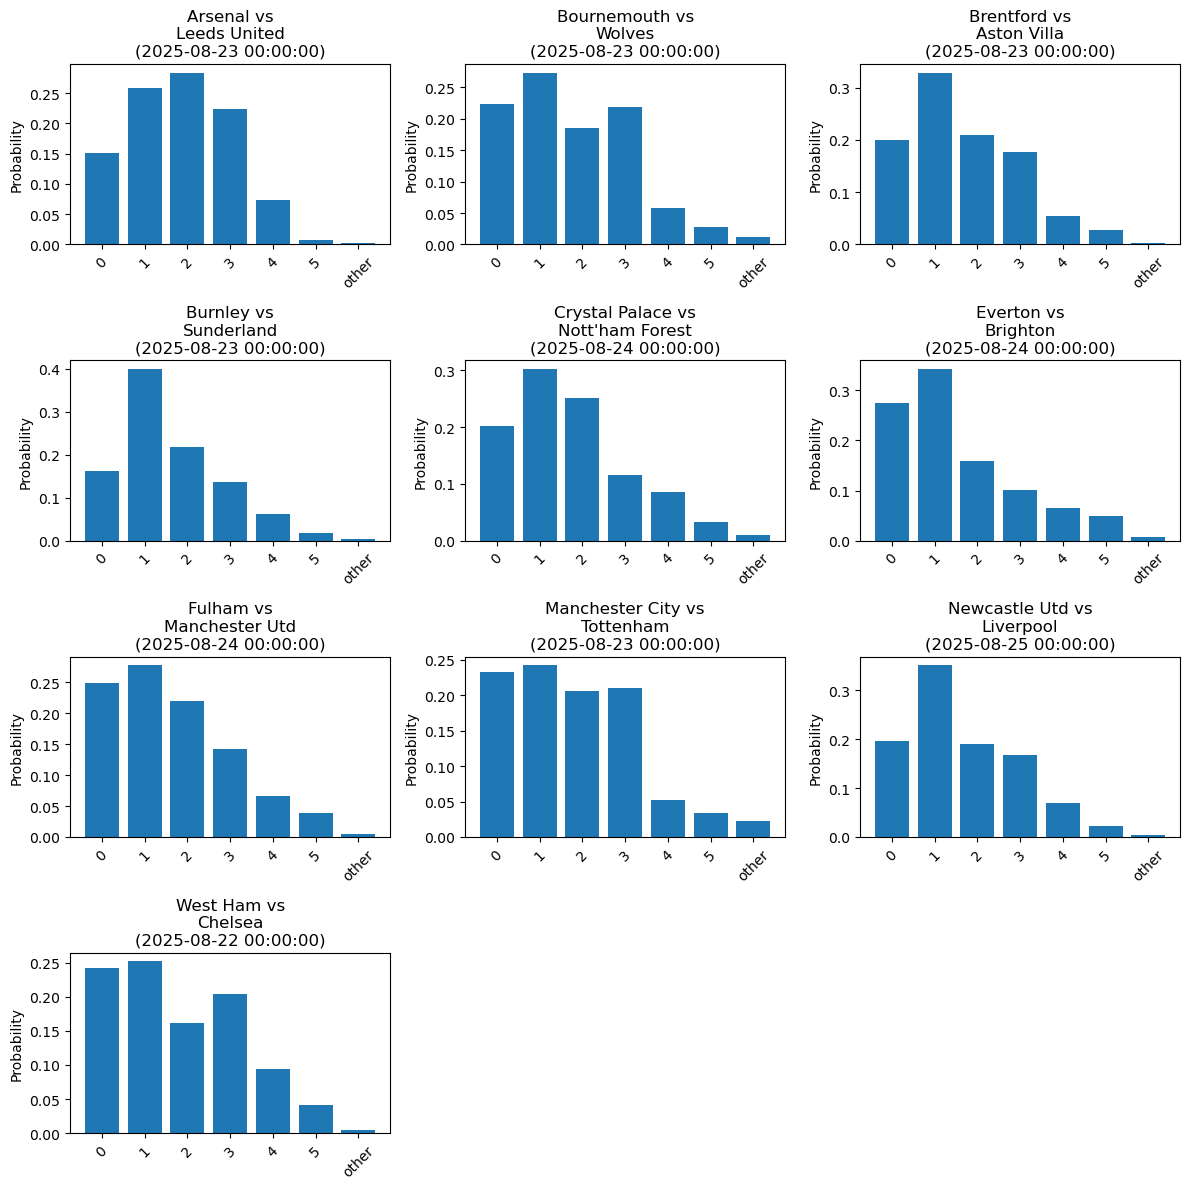

In [25]:
plot_predictions_distribution(predictions, 'premier_league', 'home_goals')

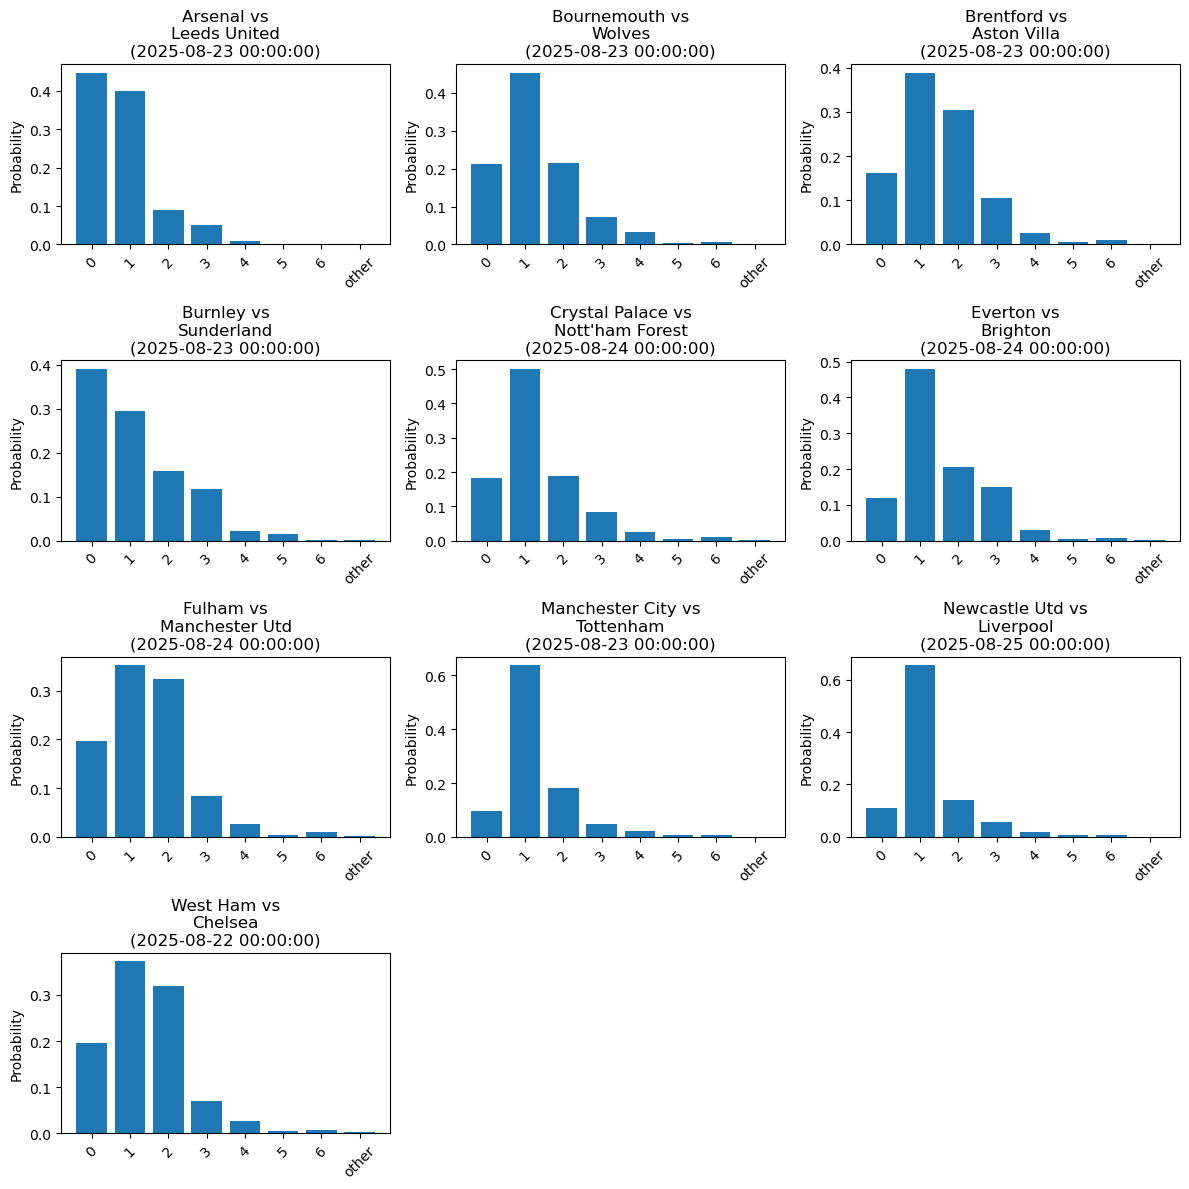

In [26]:
plot_predictions_distribution(predictions, 'premier_league', 'away_goals')

In [ ]:
# Compute total goals probability distribution assuming independence
total_goals_predictions = {}

for competition in predictions:
    home_df = predictions[competition]['home_goals']
    away_df = predictions[competition]['away_goals']
    meta_cols = ['home', 'away', 'date']
    home_prob_cols = [col for col in home_df.columns if col not in meta_cols]
    away_prob_cols = [col for col in away_df.columns if col not in meta_cols]

    # Convert column names to int if possible, ignore 'other'
    home_goal_vals = [int(col) for col in home_prob_cols if col != 'other']
    away_goal_vals = [int(col) for col in away_prob_cols if col != 'other']

    max_home = max(home_goal_vals)
    max_away = max(away_goal_vals)
    max_total = max_home + max_away

    total_goal_vals = list(range(0, max_total+1))
    total_goal_dist = []

    for idx in range(len(home_df)):
        home_probs = home_df.loc[idx, [str(g) for g in home_goal_vals]].values
        away_probs = away_df.loc[idx, [str(g) for g in away_goal_vals]].values

        # Compute joint distribution
        joint = np.outer(home_probs, away_probs)
        total_probs = np.zeros(max_total+1)
        for h in range(len(home_goal_vals)):
            for a in range(len(away_goal_vals)):
                total = home_goal_vals[h] + away_goal_vals[a]
                total_probs[total] += joint[h, a]
        # Optionally add 'other' probability (goals outside range)
        other_prob = home_df.loc[idx, 'other'] + away_df.loc[idx, 'other']
        total_probs = np.append(total_probs, other_prob)
        row = list(home_df.loc[idx, meta_cols]) + total_probs.tolist()
        total_goal_dist.append(row)

    total_goal_cols = meta_cols + [str(g) for g in total_goal_vals] + ['other']
    total_goals_predictions[competition] = pd.DataFrame(total_goal_dist, columns=total_goal_cols)

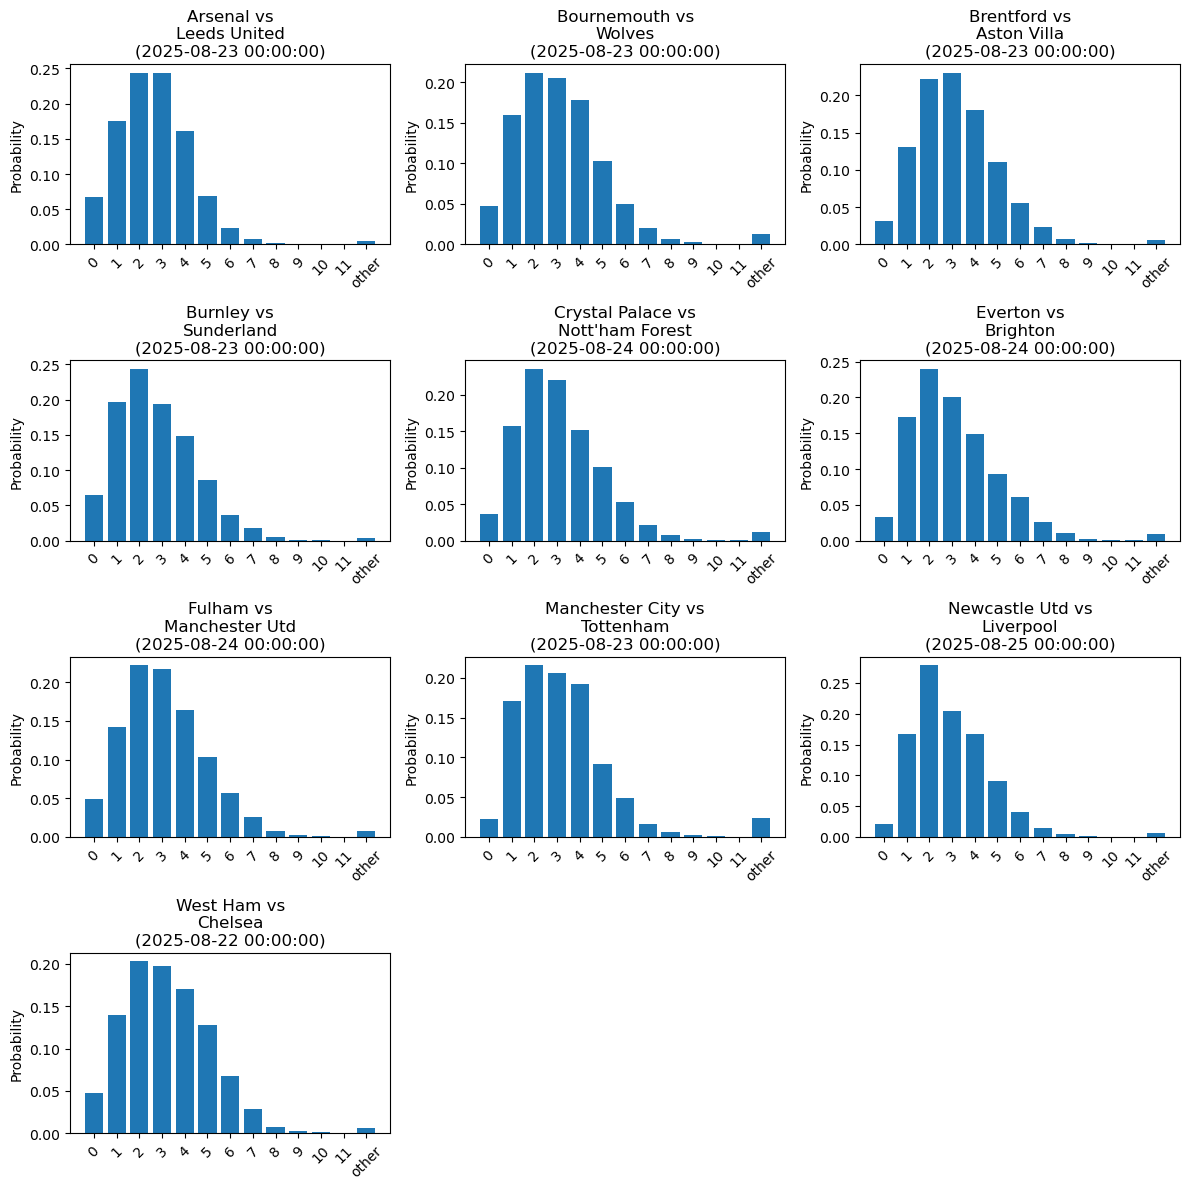

In [ ]:
# The plotting function expects the 'date' column to be datetime64[ns], but in total_goals_predictions['premier_league'] it's likely object.
# Convert 'date' column to datetime
df = total_goals_predictions['premier_league'].copy()
df['date'] = pd.to_datetime(df['date'])

# Use the existing plot_predictions_distribution function
plot_predictions_distribution({'premier_league': {'total_goals': df}}, 'premier_league', 'total_goals')

In [ ]:
# For each match, find the smallest total goals value where cumulative probability >= 0.5
cutoff_results = []

df = total_goals_predictions['premier_league']
goal_cols = [col for col in df.columns if col not in ['home', 'away', 'date', 'other']]
for idx, row in df.iterrows():
    probs = row[goal_cols].values
    cum_probs = probs.cumsum()
    # Find the first total goals value where cumulative probability >= 0.5
    cutoff_idx = np.searchsorted(cum_probs, 0.5)
    cutoff_goal = int(goal_cols[cutoff_idx]) if cutoff_idx < len(goal_cols) else None
    cutoff_results.append({
        'home': row['home'],
        'away': row['away'],
        'date': row['date'],
        'cutoff_goal': cutoff_goal,
        'cum_prob': cum_probs[cutoff_idx] if cutoff_idx < len(cum_probs) else None
    })

cutoff_df = pd.DataFrame(cutoff_results)
cutoff_df

,home,away,date,cutoff_goal,cum_prob
0,Arsenal,Leeds United,2025-08-23,3,0.730788
1,Bournemouth,Wolves,2025-08-23,3,0.624964
2,Brentford,Aston Villa,2025-08-23,3,0.614230
3,Burnley,Sunderland,2025-08-23,2,0.505161
4,Crystal Palace,Nott'ham Forest,2025-08-24,3,0.649754
5,Everton,Brighton,2025-08-24,3,0.645069
6,Fulham,Manchester Utd,2025-08-24,3,0.630614
7,Manchester City,Tottenham,2025-08-23,3,0.615877
8,Newcastle Utd,Liverpool,2025-08-25,3,0.671892
9,West Ham,Chelsea,2025-08-22,3,0.587436
